In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

In [2]:
# 2. Load Dataset
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,Thalassemia,HeartDisease
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


In [3]:
# 3. Data Understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             303 non-null    float64
 1   Sex             303 non-null    float64
 2   ChestPainType   303 non-null    float64
 3   RestingBP       303 non-null    float64
 4   Cholesterol     303 non-null    float64
 5   FastingBS       303 non-null    float64
 6   RestingECG      303 non-null    float64
 7   MaxHR           303 non-null    float64
 8   ExerciseAngina  303 non-null    float64
 9   Oldpeak         303 non-null    float64
 10  ST_Slope        303 non-null    float64
 11  MajorVessels    303 non-null    float64
 12  Thalassemia     303 non-null    float64
 13  HeartDisease    303 non-null    float64
dtypes: float64(14)
memory usage: 33.4 KB


In [4]:
df.isnull().sum()

Age               1
Sex               1
ChestPainType     1
RestingBP         1
Cholesterol       1
FastingBS         1
RestingECG        1
MaxHR             1
ExerciseAngina    1
Oldpeak           1
ST_Slope          1
MajorVessels      1
Thalassemia       1
HeartDisease      1
dtype: int64

In [5]:
df[df.isnull().any(axis=1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,Thalassemia,HeartDisease
303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
# 4. Data Cleaning
df = df.dropna()
df = df.drop_duplicates()

In [8]:
df.shape

(302, 14)

In [9]:
# 5. Exploratory Data Analysis
df['HeartDisease'].value_counts()

HeartDisease
1.0    164
0.0    138
Name: count, dtype: int64

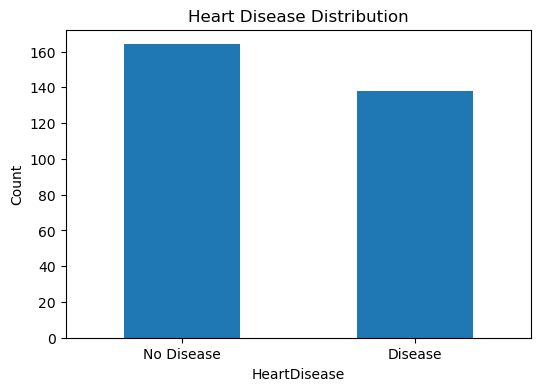

In [10]:
plt.figure(figsize=(6,4))
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xticks([0,1], ['No Disease','Disease'], rotation=0)
plt.ylabel("Count")
plt.savefig('heart_disease_distribution.png', dpi=300)
plt.show()

<Figure size 600x400 with 0 Axes>

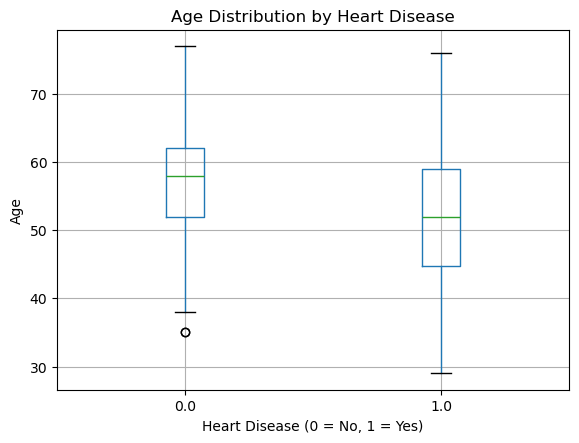

In [11]:
plt.figure(figsize=(6,4))
df.boxplot(column='Age', by='HeartDisease')
plt.title("Age Distribution by Heart Disease")
plt.suptitle('')
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.savefig('boxplot_heart_disease.png', dpi=300)
plt.show()

In [12]:
# 6. Train-Test Split
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# 7. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# 8. Model Training
model = LogisticRegression(random_state=42, max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [16]:
# 9. Model Evaluation
# Predict probability
y_prob = model.predict_proba(X_test)[:, 1]

# Custom threshold
threshold = 0.1
y_pred = (y_prob >= threshold).astype(int)

In [17]:
print("=== Model Evaluation with Custom Threshold (0.1) ===\n")

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Insight / Penjelasan Bilingual
print("\nInsight / Penjelasan:")
print("Lower threshold (0.1) increases Recall → more positive cases detected")
print("Trade-off: Precision may decrease")
print("Threshold rendah (0.1) meningkatkan Recall → lebih banyak pasien positif terdeteksi")
print("Trade-off: Presisi mungkin menurun")

=== Model Evaluation with Custom Threshold (0.1) ===

Accuracy: 0.7213

Confusion Matrix:
[[12 16]
 [ 1 32]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.43      0.59        28
         1.0       0.67      0.97      0.79        33

    accuracy                           0.72        61
   macro avg       0.79      0.70      0.69        61
weighted avg       0.78      0.72      0.70        61

ROC-AUC Score: 0.8647

Insight / Penjelasan:
Lower threshold (0.1) increases Recall → more positive cases detected
Trade-off: Precision may decrease
Threshold rendah (0.1) meningkatkan Recall → lebih banyak pasien positif terdeteksi
Trade-off: Presisi mungkin menurun


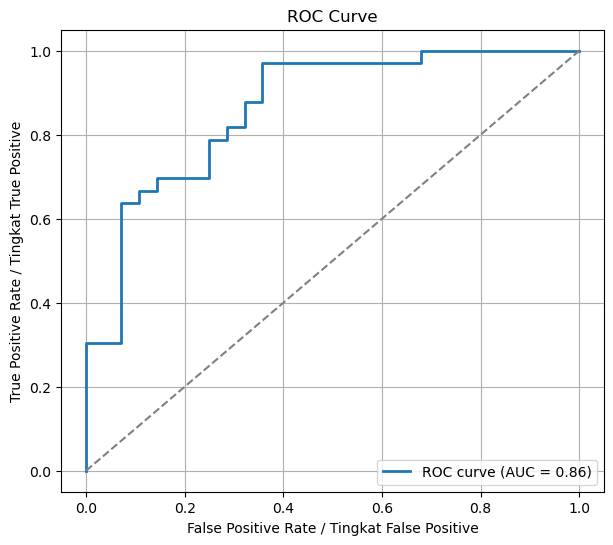


Interpretation / Interpretasi:
ROC curve closer to top-left → better model performance
Kurva ROC lebih dekat ke kiri-atas → performa model lebih baik
AUC Score / Nilai AUC: 0.8647


In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate / Tingkat False Positive')
plt.ylabel('True Positive Rate / Tingkat True Positive')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('roc.png', dpi=300)
plt.show()

# Insight / Penjelasan
print("\nInterpretation / Interpretasi:")
print("ROC curve closer to top-left → better model performance")
print("Kurva ROC lebih dekat ke kiri-atas → performa model lebih baik")
print(f"AUC Score / Nilai AUC: {roc_auc:.4f}")

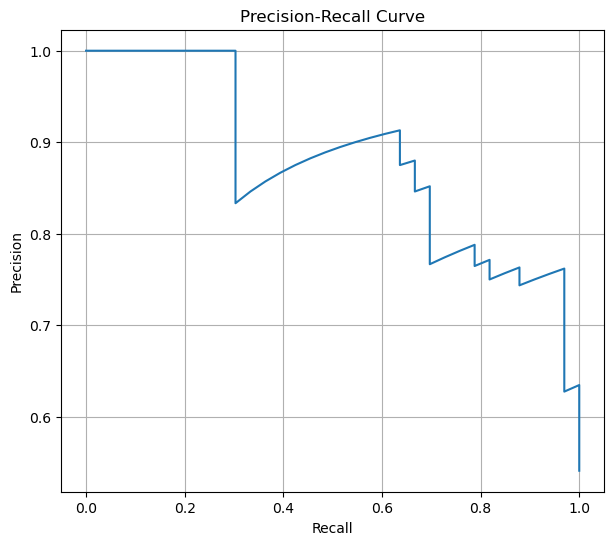

In [19]:
# 10. Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.savefig('precision_recall_curve.png', dpi=300)
plt.show()

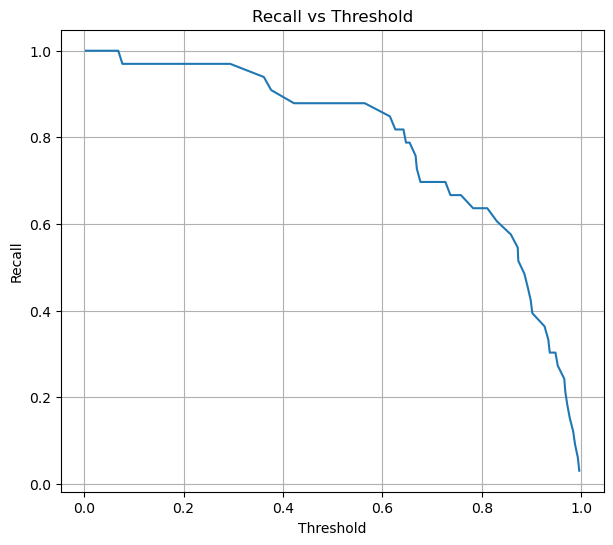

In [20]:
# 11. Recall vs Threshold Analysis
plt.figure(figsize=(7,6))
plt.plot(thresholds_pr, recall[:-1])
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold")
plt.grid(True)
plt.savefig('recall_vs_threshold.png', dpi=300)
plt.show()

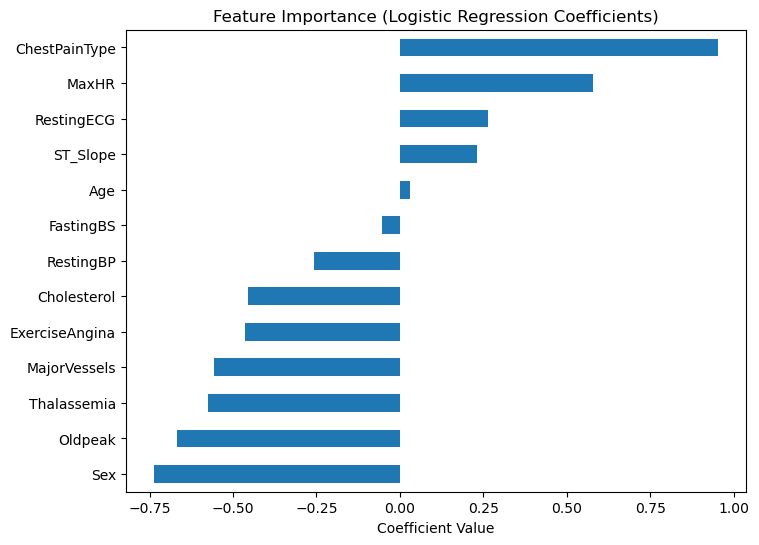

Positive coefficient → increases heart disease risk
Negative coefficient → decreases heart disease risk


In [21]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind='barh')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.savefig('logistic_regression_heart_disease.png', dpi=300)
plt.show()

print("Positive coefficient → increases heart disease risk")
print("Negative coefficient → decreases heart disease risk")